# Objective
**- To classify the given disease normal pneumonia Tuberculosis universal_test**<br>
**- Multiclass classification problem**<br>

# Dependencies

In [13]:
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array

print(tf.__version__)
############ settings ############
data_dir = r"data"

batch_size = 32
img_height = 128
img_width = 128

2.18.0


# Data preprocessing

**- Loading and splitting data<br>**
**- Train:80% and Validation:20%**

In [2]:

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,

    validation_split=0.2,

    subset="training",

    seed=123,

    image_size=(img_height, img_width),

    batch_size=batch_size)


val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,

    validation_split=0.2,

    subset="validation",

    seed=123,

    image_size=(img_height, img_width),

    batch_size=batch_size)

Found 18737 files belonging to 4 classes.
Using 14990 files for training.
Found 18737 files belonging to 4 classes.
Using 3747 files for validation.


# EDA

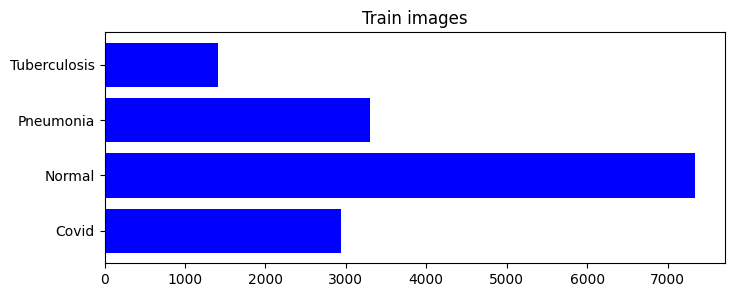

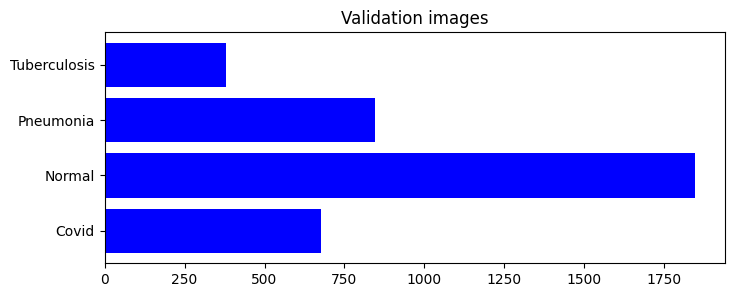

In [3]:
def plot_distribution(y, title):
    a = Counter(y)
    y = ['Covid', 'Normal', 'Pneumonia', 'Tuberculosis']

    x = [a[i] for i in range(4)]
    plt.figure(figsize=(8, 3))
    plt.barh(y, x, color='blue')
    plt.title(title)
    return plt.show()


y_train = np.concatenate([y for x, y in train_ds], axis=0)
y_val = np.concatenate([y for x, y in val_ds], axis=0)

plot_distribution(y_train, title="Train images")
plot_distribution(y_val, title="Validation images")

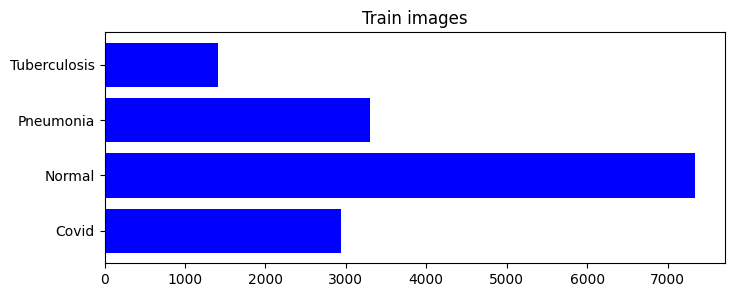

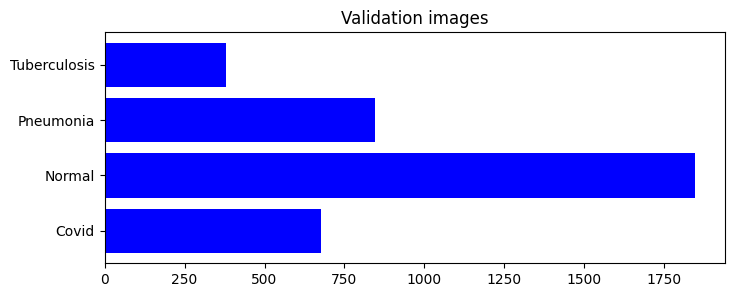

In [4]:
# Target distribution

y_train = np.concatenate([y for x, y in train_ds], axis=0)
y_val = np.concatenate([y for x, y in val_ds], axis=0)

plot_distribution(y_train, title="Train images")
plot_distribution(y_val, title="Validation images")

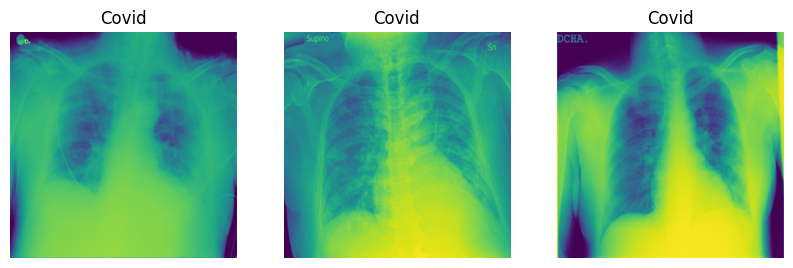

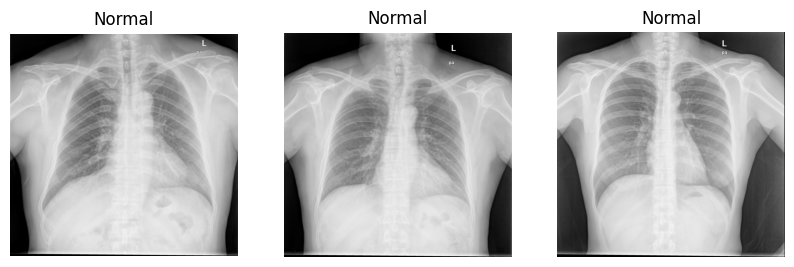

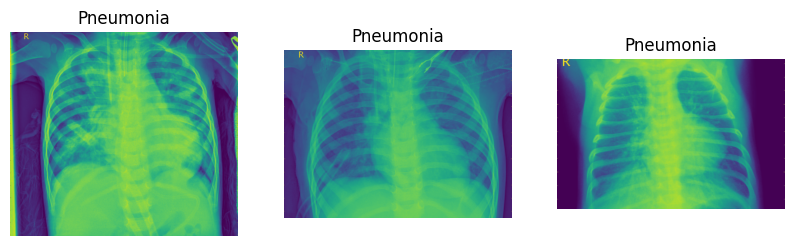

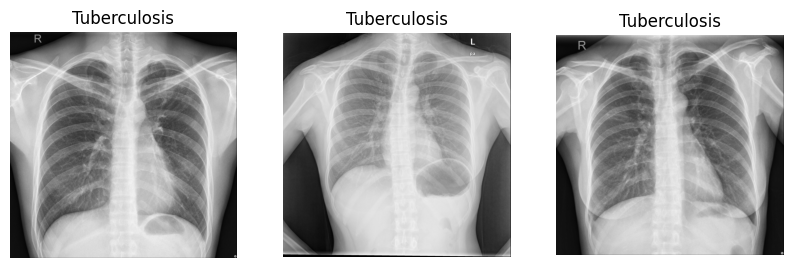

In [5]:
# Sample images
class_names = train_ds.class_names

for class_name in class_names:
    imgs = os.listdir(os.path.join(data_dir, class_name))[:3]
    plt.figure(figsize=(10, 10))
    for i, img in enumerate(imgs):
        ax = plt.subplot(3, 3, i+1)
        plt.imshow(plt.imread(os.path.join(data_dir, class_name, img)))
        plt.title(class_name)
        plt.axis('off')

# Model Training

In [6]:
# Configure the dataset for performance

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Model Evaluation

# Post Processing

In [8]:
# Model architecture - ResNet-101
num_classes = 4

# Create ResNet-101 model with pre-trained ImageNet weights
base_model = tf.keras.applications.ResNet101(
    weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

# Freeze the layers of the pre-trained model
base_model.trainable = False

# Build the custom model on top of ResNet-101
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Early stopping callback
earlystop_callback = tf.keras.callbacks.EarlyStopping(monitor='val_accuracy',
                                                      min_delta=0.0001,
                                                      patience=5)


In [9]:
# Train the model
history = model.fit(train_ds,
                    validation_data=val_ds,
                    epochs=20,
                    callbacks=[earlystop_callback])


Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 497s 1s/step - accuracy: 0.7288 - loss: 0.8243 - val_accuracy: 0.8636 - val_loss: 0.3617
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 467s 995ms/step - accuracy: 0.8338 - loss: 0.4264 - val_accuracy: 0.8831 - val_loss: 0.3240
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 460s 981ms/step - accuracy: 0.8565 - loss: 0.3773 - val_accuracy: 0.8924 - val_loss: 0.2869
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 463s 987ms/step - accuracy: 0.8701 - loss: 0.3495 - val_accuracy: 0.9002 - val_loss: 0.2600
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 458s 977ms/step - accuracy: 0.8824 - loss: 0.3120 - val_accuracy: 0.9087 - val_loss: 0.2455
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 461s 982ms/step - accuracy: 0.8926 - loss: 0.2855 - val_accuracy: 0.9101 - val_loss: 0.2370
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 462s 985ms/step - accuracy: 0.8967 - loss: 0.2667 - val_accuracy: 0.9183 - val_loss: 0.2328
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 463s 987ms/step - accuracy: 0.9023 - lo

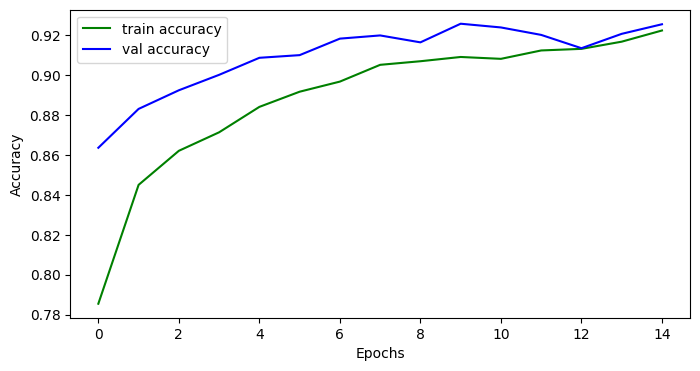

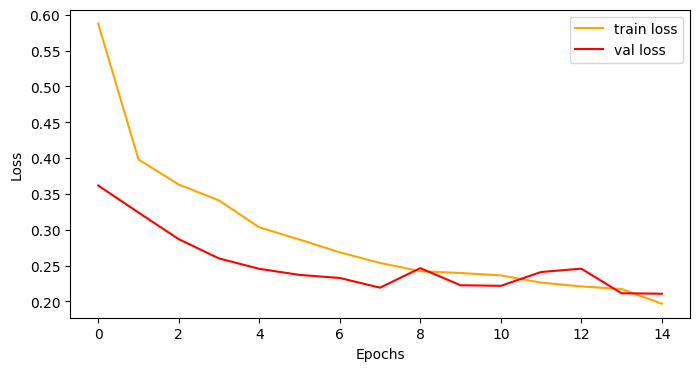

118/118 ━━━━━━━━━━━━━━━━━━━━ 94s 795ms/step - accuracy: 0.9271 - loss: 0.2042
Validation accuracy: 0.93
Validation loss: 0.21
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 782ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 814ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 848ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 783ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 777ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 782ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 821ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 824ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 894ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 808ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 755ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 779ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 765ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 763ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 797ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 814ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 773ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 763ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 792ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 775ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 781ms/step
1/1 ━━━━━━━━━━━━━━━

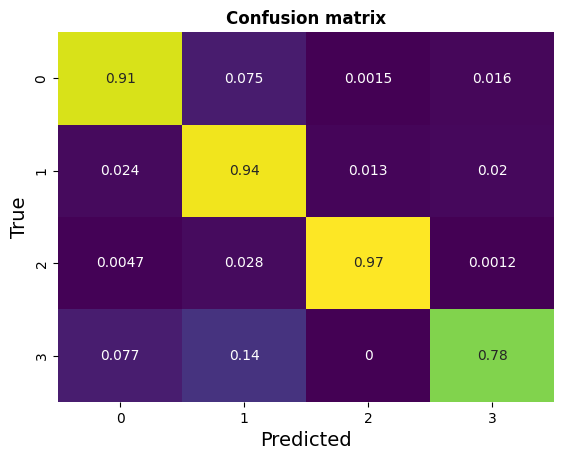

In [10]:
# Plot accuracy and loss
train_loss = history.history['loss']
train_acc = history.history['accuracy']
valid_loss = history.history['val_loss']
valid_acc = history.history['val_accuracy']

# Accuracy plots
plt.figure(figsize=(8, 4))
plt.plot(train_acc, color='green', linestyle='-', label='train accuracy')
plt.plot(valid_acc, color='blue', linestyle='-', label='val accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss plots
plt.figure(figsize=(8, 4))
plt.plot(train_loss, color='orange', linestyle='-', label='train loss')
plt.plot(valid_loss, color='red', linestyle='-', label='val loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()





In [11]:
# Evaluate the model
loss, acc = model.evaluate(val_ds, batch_size=batch_size)
print("Validation accuracy:", round(acc, 2))
print("Validation loss:", round(loss, 2))

118/118 ━━━━━━━━━━━━━━━━━━━━ 96s 805ms/step - accuracy: 0.9270 - loss: 0.2131
Validation accuracy: 0.93
Validation loss: 0.21


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 887ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 785ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 775ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 831ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 881ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 806ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 839ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 802ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 801ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 847ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 798ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 822ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 838ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 761ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 753ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 754ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 800ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 819ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 850ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 849ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 782ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 780ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 848ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 783ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 770ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

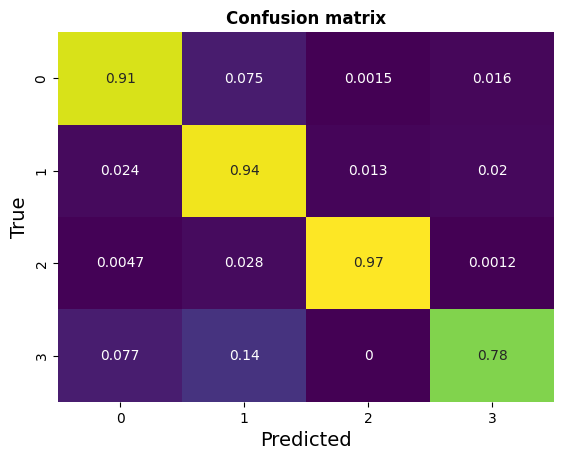

In [12]:
# Confusion matrix
y_pred = []  # store predicted labels
y_true = []  # store true labels

# Iterate over the dataset
for image_batch, label_batch in val_ds:
    # Append true labels
    y_true.append(label_batch)
    # Compute predictions
    preds = model.predict(image_batch)
    # Append predicted labels
    y_pred.append(np.argmax(preds, axis=-1))

# Convert the true and predicted labels into tensors
correct_labels = tf.concat([item for item in y_true], axis=0)
predicted_labels = tf.concat([item for item in y_pred], axis=0)
cm = confusion_matrix(correct_labels, predicted_labels, normalize='true')

# Plot the confusion matrix
sns.heatmap(cm, annot=True, cmap='viridis', cbar=None)
plt.title("Confusion matrix", fontweight='bold')
plt.ylabel("True", fontsize=14)
plt.xlabel("Predicted", fontsize=14)
plt.show()

In [14]:
# Save the model
model.save("Lung_model.keras")

In [14]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
model = load_model("models/Lung_model.keras")
def prediction(img):
    class_names = ['Covid', 'Normal', 'Pneumonia', 'Tuberculosis']

    my_image = load_img(img, target_size=(img_height, img_width))
    my_image = img_to_array(my_image)
    my_image = np.expand_dims(my_image, 0)

    out = np.round(model.predict(my_image)[0], 2)
    fig = plt.figure(figsize=(7, 4))
    plt.barh(class_names, out, color='lightgray',
             edgecolor='red', linewidth=1, height=0.5)

    for index, value in enumerate(out):
        plt.text(value/2 + 0.1, index, f"{100*value:.2f}%", fontweight='bold')

    plt.xticks([])
    plt.yticks([0, 1, 2, 3], labels=class_names,
               fontweight='bold', fontsize=14)
    fig.savefig('pred_img.png', bbox_inches='tight')
    return plt.show()

c:\Users\hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 6 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


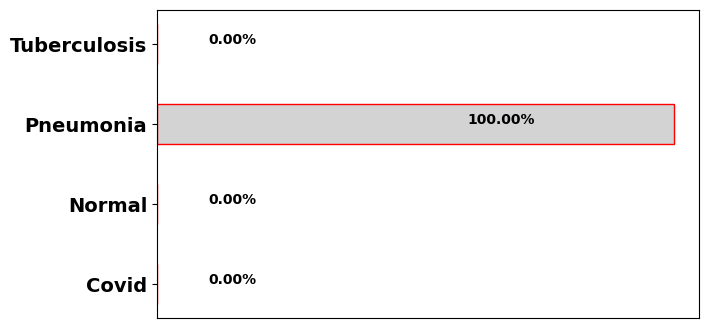

In [16]:
img = 'data/universal_test/Pneumonia/BACTERIA-213622-0002.jpeg'
prediction(img)

In [17]:
print(classification_report(correct_labels, predicted_labels))

              precision    recall  f1-score   support

           0       0.89      0.91      0.90       678
           1       0.93      0.94      0.94      1846
           2       0.97      0.97      0.97       844
           3       0.86      0.78      0.82       379

    accuracy                           0.93      3747
   macro avg       0.91      0.90      0.91      3747
weighted avg       0.93      0.93      0.93      3747



In [18]:
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Load the same model as Flask
model = load_model("models/Lung_model.keras")

def test_model_prediction(img_path):
    img_height, img_width = 128, 128  # Ensure correct size
    img = load_img(img_path, target_size=(img_height, img_width))  # Load image
    img = img_to_array(img)  # Convert to NumPy array
    img = np.expand_dims(img, axis=0)  # Add batch dimension

    prediction = model.predict(img)
    print(f"Raw model output: {prediction}")  # Print model predictions

    class_names = ['Covid', 'Normal', 'Pneumonia', 'Tuberculosis']
    predicted_class = class_names[np.argmax(prediction)]
    print(f"Predicted Class: {predicted_class}")
    print(f"Prediction Probabilities: {prediction}")

# Run the test with an image
test_model_prediction("data/universal_test/Pneumonia/BACTERIA-213622-0002.jpeg")  # Replace with an actual X-ray image path


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Raw model output: [[2.2667191e-11 1.2645435e-06 9.9999869e-01 3.8586443e-11]]
Predicted Class: Pneumonia
Prediction Probabilities: [[2.2667191e-11 1.2645435e-06 9.9999869e-01 3.8586443e-11]]
